# Simple linear regression


In [1]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Loading the dataset
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df =pd.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
519,2014,HYUNDAI,TUCSON,SUV - SMALL,2.4,4,A6,X,11.3,8.3,10.0,28,230
235,2014,CHEVROLET,ORLANDO,SUV - SMALL,2.4,4,AS6,X,12.2,8.6,10.6,27,244
795,2014,MINI,COOPER S CONVERTIBLE,MINICOMPACT,1.6,4,M6,Z,9.1,6.7,8.0,35,184
584,2014,JEEP,GRAND CHEROKEE 4X4 (MDS),SUV - STANDARD,5.7,8,A8,X,17.3,11.7,14.8,19,340
185,2014,CADILLAC,XTS,FULL-SIZE,3.6,6,AS6,X,13.6,8.6,11.4,25,262


In [3]:
# Understanding the data
df.describe()


,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [4]:
# Selecting the features
cdf = df[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB","CO2EMISSIONS"]]
cdf.sample(7)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
76,2.0,4,8.4,193
900,3.4,6,10.4,239
301,6.4,8,13.8,317
1066,3.2,6,12.8,294
707,2.0,4,7.0,161
1016,2.0,4,9.1,209
335,1.4,4,7.2,166


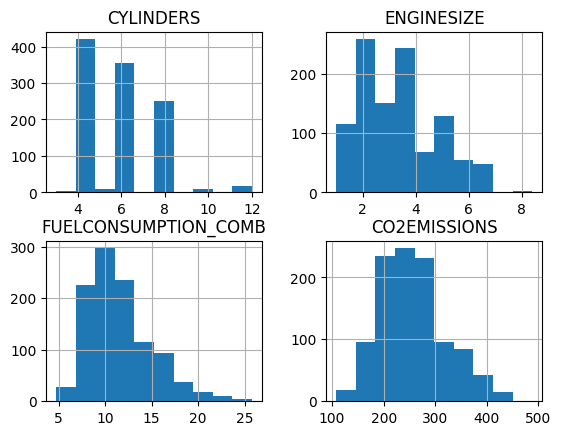

In [5]:
# visualizing the features in the dataset
viz = cdf[["CYLINDERS","ENGINESIZE","FUELCONSUMPTION_COMB","CO2EMISSIONS"]]
viz.hist()
plt.show()

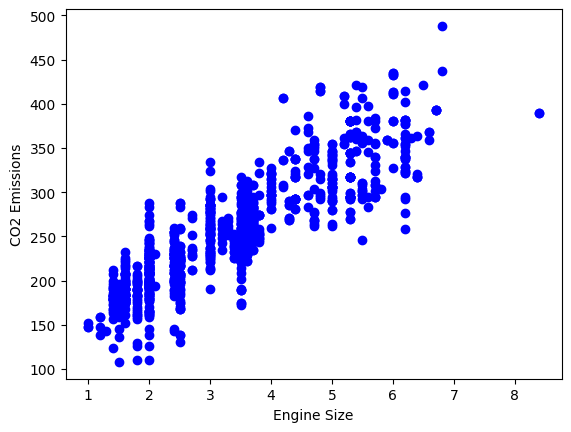

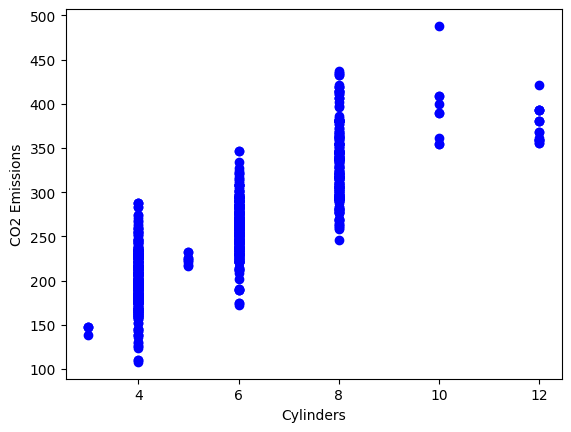

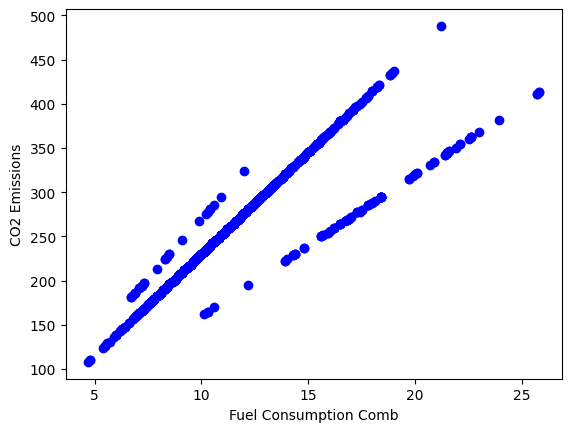

In [6]:
# plotting each of the features against the Emission, to see how linear their relationship is
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color="blue")
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.show()

plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color="blue")
plt.xlabel("Cylinders")
plt.ylabel("CO2 Emissions")
plt.show()

plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color="blue")
plt.xlabel("Fuel Consumption Comb")
plt.ylabel("CO2 Emissions")
plt.show()

In [7]:
# using the engine size as the feature and the emission as the target variable
# creating the feature and target arrays
x = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()
print("x.shape: ", x.shape)
print("y.shape: ", y.shape)
print(pd.DataFrame(x).head(3))
print(pd.DataFrame(y).head(3))

x.shape:  (1067,)
y.shape:  (1067,)
     0
0  2.0
1  2.4
2  1.5
     0
0  196
1  221
2  136


In [8]:
# training and testing dataset

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
type(x_train), np.shape(x_train), np.shape(y_train)



(numpy.ndarray, (853,), (853,))

In [9]:
regressor = linear_model.LinearRegression()
regressor.fit(x_train.reshape(-1, 1), y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
print("Coefficients: ", regressor.coef_[0])
print("Intercept: ", regressor.intercept_)


Coefficients:  38.992978724434074
Intercept:  126.28970217408721


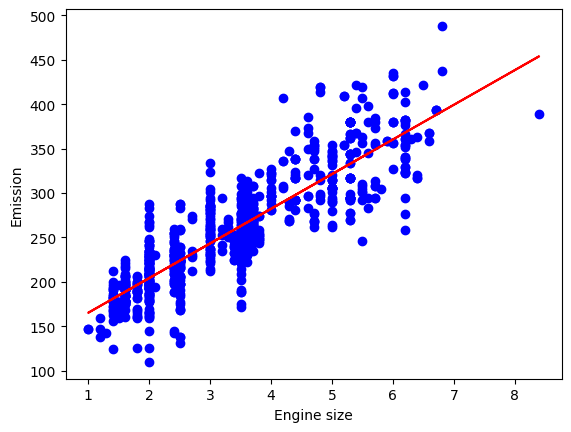

In [11]:
# plotting the regression line
plt.scatter(x_train, y_train,  color='blue')
plt.plot(x_train, regressor.coef_[0]*x_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [12]:

# Use the predict method to make test predictions
y_pred = regressor.predict(x_test.reshape(-1,1))
print("Predictions: ", y_pred[0:5])

# model evaluation of the model using mse, mae. rmse, r2-score
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Predictions:  [309.55670218 262.76512771 266.66442558 243.26863835 204.27565962]
Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76
